# Setup

### Imports

In [1]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.base import clone as sk_clone
import cloudpickle

### Constants

In [2]:
SEED = 42
FEATURES = ["temperature", "humidity", "wind_direction", "wind_speed", "precipitation", "light"]

### Set splitting

In [3]:
def split_set(X, y, seed):
    X_tune, X_test, y_tune, y_test = train_test_split(X, y, test_size=.2, random_state=seed)
    X_train, X_validate, y_train, y_validate = train_test_split(X_tune, y_tune, test_size=.2, random_state=seed)
    return ((X_train, y_train), (X_validate, y_validate), (X_test, y_test))

In [4]:
def get_sets(data, seed=42, do_split=True, drop_y_nan=True):
    y_labels = [label for label in data.columns if label.startswith("future_")]

    if drop_y_nan:
        data = data.dropna(subset=y_labels)
    X = data.drop([*y_labels], axis="columns")
    y = data[y_labels]

    if do_split:
        return split_set(X, y, seed)
    else:
        return (X, y)

### Metrics

In [5]:
from sklearn.metrics import r2_score, root_mean_squared_error

def compute_metrics(estimator, sets):
    n_features = sets[0][2].shape[1]
    metrics = [("r2", r2_score), ("RMSE", root_mean_squared_error)]
    metric_outputs = {"feature": [*(sets[0][2].iloc[:, i].name for i in range(n_features)), "all"]}
    predictions = [estimator.predict(set[1]) for set in sets]

    for metric_label, metric in metrics:
        for set_idx, (set_label, _, y) in enumerate(sets):
            for feature_idx in range(n_features):
                metric_outputs.setdefault(f"{metric_label}_{set_label}", [])
                metric_outputs[f"{metric_label}_{set_label}"].append(metric(y.iloc[:, feature_idx], [row[feature_idx] for row in predictions[set_idx]]))
            metric_outputs[f"{metric_label}_{set_label}"].append(metric(y, predictions[set_idx]))
    print(pd.DataFrame(metric_outputs))

def score_model(model, sets, score_test=False):
    sets_to_score = [("train", *(sets[0])), ("validate", *(sets[1]))]
    if score_test:
        sets_to_score.append(("test", *(sets[2])))
    compute_metrics(model, sets_to_score)

def fit_and_score(model, sets, score_test=False):
    model.fit(*(sets[0]))
    score_model(model, sets, score_test=score_test)


### Plotting

In [6]:
def plot_predictions(model, input, hours, just: list[str] | None = None):
    labels = input.columns.to_list()
    labels.remove("time")


    rows = []
    for row in input.iloc:
        rows.extend([row] * hours)
    inputs = pd.DataFrame(rows, columns=input.columns)
    inputs["prediction_offset"] = list(range(hours)) * len(input)
    predictions = model.predict(inputs)

    if just is not None:
        allowed_outputs = [labels.index(output) for output in just]
        old_predictions = predictions
        predictions = []
        for row in old_predictions:
            prediction_row = []
            for i, prediction in enumerate(row):
                if i in allowed_outputs:
                    prediction_row.append(prediction)
            predictions.append(prediction_row)
        labels = just

    plt.figure()
    plt.plot(range(hours), predictions)
    plt.legend(labels)
    plt.show()

### Pipeline functions

In [7]:
def drop_columns(X, columns):
    return X.drop(columns, axis="columns", errors="ignore")

def drop_nan(X):
    return X.dropna()

def move_column(X, idx, col_name):
    column_to_move = X.pop(col_name)
    X.insert(idx, col_name, column_to_move)
    return X

def rename_columns(X, name_map):
    return X.rename(columns=name_map)

def drop_before(X, before_date):
    return X.drop(X[X["time"] < before_date.timestamp()].index)

def drop_after(X, after_date):
    return X.drop(X[X["time"] >= after_date.timestamp()].index)

def _encode_cyclic(value, range_start, range_stop):
    value = (value - range_start) / (range_stop - range_start)
    x = np.sin(2 * np.pi * value)
    y = np.cos(2 * np.pi * value)
    return x, y

def encode_cyclic(X, feature, range_start, range_stop, new_feature_suffix=None, remove_old=False, get_feature=None):
    if get_feature is None:
        def get_feature(row):
            return row[feature]
    if new_feature_suffix is None:
        new_feature_suffix = feature
    X[f"{new_feature_suffix}_sin"] = X[[feature]].apply(lambda row: _encode_cyclic(get_feature(row), range_start, range_stop)[0], axis="columns")
    X[f"{new_feature_suffix}_cos"] = X[[feature]].apply(lambda row: _encode_cyclic(get_feature(row), range_start, range_stop)[1], axis="columns")
    if remove_old:
        X.drop([feature], inplace=True, axis="columns")
    return X

def split_time(X, year=True, month=True, day=True, hour=True, minute=False, second=False, make_cyclic=False, remove_old=True):
    X = X.copy()
    if year:
        X["year"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).year, axis="columns")
    if month:
        if not make_cyclic:
            X["month"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).month, axis="columns")
        else:
            encode_cyclic(X, "time", 1, 12, new_feature_suffix="month", get_feature=lambda row: datetime.fromtimestamp(row["time"]).month)
    if day:
        if not make_cyclic:
            X["day"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).day, axis="columns")
        else:
            encode_cyclic(X, "time", 1, 31, new_feature_suffix="day", get_feature=lambda row: datetime.fromtimestamp(row["time"]).day)
    if hour:
        if not make_cyclic:
            X["hour"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).hour, axis="columns")
        else:
            encode_cyclic(X, "time", 0, 23, new_feature_suffix="hour", get_feature=lambda row: datetime.fromtimestamp(row["time"]).hour)
    if minute:
        if not make_cyclic:
            X["minute"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).minute, axis="columns")
        else:
            encode_cyclic(X, "time", 0, 59, new_feature_suffix="minute", get_feature=lambda row: datetime.fromtimestamp(row["time"]).minute)
    if second:
        if not make_cyclic:
            X["second"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).second, axis="columns")
        else:
            encode_cyclic(X, "time", 0, 59, new_feature_suffix="second", get_feature=lambda row: datetime.fromtimestamp(row["time"]).second)


    if remove_old:
        X.drop(["time"], axis="columns", inplace=True)

    return X

### Read data

In [24]:
raw_data = pd.read_parquet(Path("../data/historical_data_06102.parquet"))
raw_data_no_nan = raw_data.dropna()

raw_data_limited = raw_data_no_nan.sample(n=100000, random_state=SEED)
sets_limited = get_sets(raw_data_limited, seed=SEED)

raw_data_ultra_limited = drop_before(raw_data_no_nan, datetime.now() - timedelta(days=365*2)).sample(n=10000, random_state=SEED)
sets_ultra_limited = get_sets(raw_data_ultra_limited, seed=SEED)

In [9]:
raw_data_iot = pd.read_parquet(Path("../data/IoT_data.parquet"))
sets_iot = get_sets(raw_data_iot.dropna(), seed=SEED)

# Experiments

## Setup Sets

In [10]:

preprocessor_no_time_split = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
])

In [11]:
preprocessor_base = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(split_time)),
])

In [12]:
preprocessor_scaled = Pipeline([
    ("base", preprocessor_base),
    ("scaler", StandardScaler())
])

In [13]:
preprocessor_cyclic = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, make_cyclic=True))),
])

In [14]:
preprocessor_cyclic_scaled = Pipeline([
    ("base", preprocessor_cyclic),
    ("scaler", StandardScaler())
])

In [15]:
preprocessor_no_year = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=False))),
])

In [16]:
preprocessor_cyclic_no_year = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=False, make_cyclic=True))),
])

In [17]:
preprocessor_cyclic_no_year_scaled = Pipeline([
    ("base", preprocessor_cyclic_no_year),
    ("scaler", StandardScaler())
])

## Best model

In [18]:
best_model = MultiOutputRegressor(
    HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=8,
        max_features=0.6,
        max_iter=200,
        max_leaf_nodes=None,
        min_samples_leaf=33,
        random_state=42,
    )
)

def get_best_model():
    return sk_clone(best_model)

In [53]:
prepreprocessor = Pipeline(
    [
        ("NaN_dropper", FunctionTransformer(lambda X: X.dropna())),
    ]
)
preprocessor = Pipeline(
    [
        ("prepreprocessor", prepreprocessor),
        (
            "time_spliter",
            FunctionTransformer(
                lambda X: split_time(
                    X, year=False, make_cyclic=True, remove_old=True
                )
            ),
        ),
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", get_best_model())
])

new_data = prepreprocessor.fit_transform(raw_data)
new_data = new_data.sample(n=1000000)

sets = get_sets(new_data, seed=SEED)
fit_and_score(model, sets)
fitted_best_model = model

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.797528     0.792362      3.063469       3.101989
1        future_humidity  0.508571     0.494301     11.151042      11.293893
2  future_wind_direction  0.219598     0.202733     83.885952      84.808911
3      future_wind_speed  0.295404     0.279157      1.483464       1.498646
4   future_precipitation  0.059433     0.026023      0.455847       0.456448
5           future_light  0.722563     0.711070  12835.288245   13077.304437
6                    all  0.433849     0.417608   2155.888003    2196.410721


In [21]:
score_model(fitted_best_model, sets, score_test=True)

                 feature  r2_train  r2_validate   r2_test    RMSE_train  \
0     future_temperature  0.800356     0.793742  0.794143      3.040848   
1        future_humidity  0.515029     0.498290  0.498421     11.093839   
2  future_wind_direction  0.221549     0.199439  0.200431     83.675135   
3      future_wind_speed  0.300760     0.280690  0.284676      1.473712   
4   future_precipitation  0.062310     0.034612  0.029101      0.455992   
5           future_light  0.715553     0.705593  0.705618  12977.975724   
6                    all  0.435926     0.418728  0.418732   2179.619208   

   RMSE_validate     RMSE_test  
0       3.085738      3.083425  
1      11.252470     11.261020  
2      84.978299     84.783588  
3       1.497859      1.493651  
4       0.441742      0.457643  
5   13216.877371  13191.615021  
6    2219.688913   2215.449058  


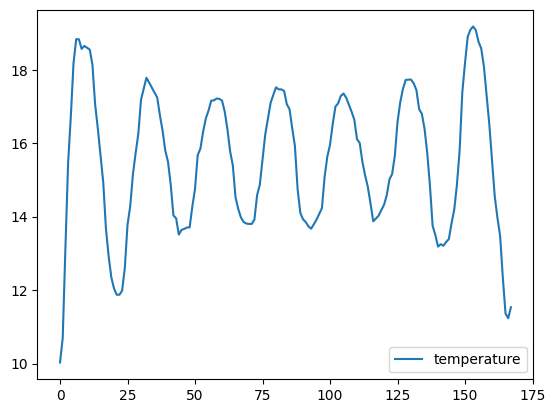

In [54]:
plot_predictions(fitted_best_model, sets_limited[1][0][:1], 24 * 7, just=["temperature"])

## Save model

In [ ]:
with open("../model.pkl", "wb") as f:
    cloudpickle.dump(fitted_best_model, f, protocol=5)

## Base

In [ ]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=5, random_state=SEED))
preprocessor = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(split_time)),
])
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])
fit_and_score(model, sets_limited)

plot_predictions(model, sets_limited[1][0][:1], 24 * 7)
plot_predictions(model, sets_limited[1][0][:1], 24 * 7, just=["temperature"])

## Models

### HistGradientBoostringRegressor

In [ ]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_base),
    ("model", model)
])
params = {
    "model__estimator__max_depth": range(5, 15),
    "model__estimator__learning_rate": [0.05, 0.1, 0.2,],
    "model__estimator__min_samples_leaf": range(30, 50),
    "model__estimator__max_iter": [10, 25, 50, 100, 200],
    "model__estimator__max_features": [0.2, 0.4, 0.6, 0.8, 1.0],
    "model__estimator__max_leaf_nodes": [None, *range(21, 60, 5)]
}
search = RandomizedSearchCV(model, params, random_state=SEED)

search_sets = sets_limited
search.fit(*search_sets[0])

print(search.best_estimator_)
compute_metrics(search.best_estimator_, [("train", *(search_sets[0])), ("validate", *(search_sets[1]))])

In [20]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year),
    ("model", model)
])
params = {
    "model__estimator__max_depth": range(5, 15),
    "model__estimator__learning_rate": [0.05, 0.1, 0.2,],
    "model__estimator__min_samples_leaf": range(30, 50),
    "model__estimator__max_iter": [10, 25, 50, 100, 200],
    "model__estimator__max_features": [0.2, 0.4, 0.6, 0.8, 1.0],
    "model__estimator__max_leaf_nodes": [None, *range(21, 60, 5)],
}
search = RandomizedSearchCV(model, params, random_state=SEED)

search_sets = sets_iot
search.fit(*search_sets[0])

print(search.best_estimator_)
compute_metrics(search.best_estimator_, [("train", *(search_sets[0])), ("validate", *(search_sets[1]))])

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('NaN_dropper',
                                  FunctionTransformer(func=<function drop_nan at 0x78f3482ca7a0>)),
                                 ('time_spliter',
                                  FunctionTransformer(func=<function <lambda> at 0x78f348143880>))])),
                ('model',
                 MultiOutputRegressor(estimator=HistGradientBoostingRegressor(learning_rate=0.05,
                                                                              max_depth=8,
                                                                              max_features=0.6,
                                                                              max_iter=200,
                                                                              max_leaf_nodes=None,
                                                                              min_samples_leaf=33,
                                                                

In [55]:
model = Pipeline([
    ("preprocessor", preprocessor_no_time_split),
    ("model", get_best_model())
])
fit_and_score(model, sets_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.765300     0.720538      3.312744       3.591599
1        future_humidity  0.418033     0.335053     12.104024      12.990552
2  future_wind_direction  0.294235     0.192539     79.655362      85.296489
3      future_wind_speed  0.345546     0.249998      1.427595       1.526217
4   future_precipitation  0.072999     0.014021      0.452042       0.485114
5           future_light  0.439164     0.341851  18271.314009   19662.630882
6                    all  0.389213     0.309000   3061.377629    3294.420142


In [56]:
model = Pipeline([
    ("preprocessor", preprocessor_base),
    ("model", get_best_model())
])
fit_and_score(model, sets_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.811282     0.768958      2.970560       3.265669
1        future_humidity  0.521916     0.441609     10.970658      11.904290
2  future_wind_direction  0.334788     0.208664     77.333028      84.440505
3      future_wind_speed  0.415486     0.301091      1.349158       1.473313
4   future_precipitation  0.065253     0.017100      0.453927       0.484355
5           future_light  0.627874     0.560315  14883.218286   16071.272421
6                    all  0.462766     0.382956   2496.049269    2695.473426


In [57]:
model = Pipeline([
    ("preprocessor", preprocessor_cyclic),
    ("model", get_best_model())
])
fit_and_score(model, sets_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.819641     0.774736      2.904025       3.224572
1        future_humidity  0.541725     0.450098     10.740975      11.813451
2  future_wind_direction  0.344031     0.211683     76.793882      84.279272
3      future_wind_speed  0.425404     0.308214      1.337663       1.465786
4   future_precipitation  0.091164     0.014067      0.447591       0.485102
5           future_light  0.665737     0.591383  14105.747883   15493.077295
6                    all  0.481283     0.391697   2366.328670    2599.057580


## Scaled

In [ ]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", model)
])
fit_and_score(model, sets_limited)

## Random forest

In [29]:
model = MultiOutputRegressor(RandomForestRegressor(random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year),
    ("model", model)
])
params = {
    "model__estimator__n_estimators": [10, 50, 100, 200],
    "model__estimator__max_depth": range(5, 15),
    "model__estimator__min_samples_leaf": range(30, 50),
    "model__estimator__max_features": [0.2, 0.4, 0.6, 0.8, 1.0],
    "model__estimator__max_leaf_nodes": [None, *range(21, 60, 5)]
}
search = RandomizedSearchCV(model, params, random_state=SEED)

search_sets = sets_iot
search.fit(*search_sets[0])

print(search.best_estimator_)
score_model(search.best_estimator_, search_sets, score_test=True)

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('NaN_dropper',
                                  FunctionTransformer(func=<function drop_nan at 0x77cbb71f2520>)),
                                 ('time_spliter',
                                  FunctionTransformer(func=<function <lambda> at 0x77cbb710fb00>))])),
                ('model',
                 MultiOutputRegressor(estimator=RandomForestRegressor(max_depth=9,
                                                                      max_features=0.8,
                                                                      max_leaf_nodes=31,
                                                                      min_samples_leaf=42,
                                                                      random_state=42)))])
                 feature  r2_train  r2_validate   r2_test    RMSE_train  \
0     future_temperature  0.440037     0.369796  0.418580      3.242440   
1        future_humidity  0.419503     0.375602

## SVM

### rbf

In [31]:
model = MultiOutputRegressor(SVR(kernel="rbf"))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.715914     0.707156      3.634016       3.694292
1        future_humidity  0.124673     0.115240     14.101223      14.016924
2  future_wind_direction  0.046709     0.050258     90.803617      88.822020
3      future_wind_speed  0.233342     0.124496      1.774506       1.924600
4   future_precipitation  0.012102     0.003745      0.590774       0.384210
5           future_light -0.355455    -0.345304  28112.125597   28271.582906
6                    all  0.129547     0.109265   4703.838289    4730.070825


In [32]:
model = MultiOutputRegressor(SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.853218     0.687979      2.612153       3.813336
1        future_humidity  0.420342     0.076430     11.475126      14.321052
2  future_wind_direction  0.264487     0.136740     79.760082      84.681537
3      future_wind_speed  0.626867     0.004135      1.237965       2.052636
4   future_precipitation  0.244062    -0.361481      0.516783       0.449148
5           future_light -0.193545    -0.187239  26379.739798   26558.824677
6                    all  0.369239     0.059427   4412.556984    4444.023731


In [66]:
model = MultiOutputRegressor(SVR(kernel="rbf"))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year_scaled),
    ("model", model)
])
params = {
    "model__estimator__C": [1, 10, 25, 50, 100],
    "model__estimator__gamma": [0.1, 0.25, 0.5, 0.75, 1.0],
    "model__estimator__epsilon": [0.1, 0.25, 0.5, 0.75, 1.0],
}
search = RandomizedSearchCV(model, params, random_state=SEED)

search_sets = sets_iot
search.fit(*search_sets[0])

print(search.best_estimator_)
compute_metrics(search.best_estimator_, [("train", *(search_sets[0])), ("validate", *(search_sets[1]))])

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('base',
                                  Pipeline(steps=[('NaN_dropper',
                                                   FunctionTransformer(func=<function drop_nan at 0x77cbb71f2520>)),
                                                  ('time_spliter',
                                                   FunctionTransformer(func=<function <lambda> at 0x77cbb710fb00>))])),
                                 ('scaler', StandardScaler())])),
                ('model',
                 MultiOutputRegressor(estimator=SVR(C=50, gamma=0.25)))])
                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.385456     0.190628      3.396788       3.785662
1        future_humidity  0.210962     0.026882     17.122118      18.608740
2  future_wind_direction  0.340164     0.327093     60.965468      58.269199
3      future_wind_speed  0.432107     0.311743      1.586012       1.814929
4   

### poly

In [33]:
model = MultiOutputRegressor(SVR(kernel="poly", degree=2))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.302132     0.278407      5.695724       5.799082
1        future_humidity  0.020529     0.032002     14.916519      14.661460
2  future_wind_direction  0.037113     0.035338     91.259525      89.516993
3      future_wind_speed  0.087334     0.030416      1.936121       2.025370
4   future_precipitation -0.000522    -0.002612      0.594537       0.385434
5           future_light -0.357833    -0.348312  28136.775052   28303.167131
6                    all  0.014792     0.004206   4708.529580    4735.925912


In [34]:
model = MultiOutputRegressor(SVR(kernel="poly", degree=3))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.691986     0.684963      3.783966       3.831720
1        future_humidity  0.111812     0.106544     14.204441      14.085639
2  future_wind_direction  0.033478     0.032738     91.431601      89.637514
3      future_wind_speed  0.198491     0.116480      1.814391       1.933391
4   future_precipitation  0.003044     0.009919      0.593476       0.383018
5           future_light -0.352922    -0.344752  28085.845548   28265.775018
6                    all  0.114315     0.100982   4699.612237    4729.274383


In [35]:
model = MultiOutputRegressor(SVR(kernel="poly", degree=8))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.426658   -57.232965      5.162608      52.095167
1        future_humidity  0.119682  -233.232833     14.141370     228.067784
2  future_wind_direction  0.050839   -80.180333     90.606707     821.189171
3      future_wind_speed  0.328388   -31.506044      1.660870      11.727181
4   future_precipitation  0.143148   -67.680688      0.550197       3.190076
5           future_light -0.339515    -0.705304  27946.345953   31830.303961
6                    all  0.121533   -78.423028   4676.411284    5491.095557


## Untrained dates

In [58]:
for include_year in [True, False]:
    pipeline_old_dates = Pipeline([
        ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1) - timedelta(days=365*2)))),
        ("after_date_dropper", FunctionTransformer(lambda X: drop_after(X, datetime(2025, 1, 1)))),
        ("NaN_dropper", FunctionTransformer(drop_nan)),
    ])

    pipeline_new_dates = Pipeline([
        ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
        ("NaN_dropper", FunctionTransformer(drop_nan)),
    ])

    print(f"===== OLD {'with' if include_year else 'without'} year =====")
    preprocessor = Pipeline([
        ("NaN_dropper", FunctionTransformer(drop_nan)),
        ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=include_year, make_cyclic=True))),
    ])
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", get_best_model())
    ])
    fit_and_score(model, get_sets(pipeline_old_dates.fit_transform(raw_data_limited)))

    print(f"===== NEW {'with' if include_year else 'without'} year =====")
    score_model(model, get_sets(pipeline_new_dates.fit_transform(raw_data_limited)))

===== OLD with year =====
                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.852930     0.774251      2.545235       3.141081
1        future_humidity  0.550971     0.336437      9.505266      11.626733
2  future_wind_direction  0.391544     0.227630     77.249681      87.432515
3      future_wind_speed  0.544006     0.319720      1.092246       1.359111
4   future_precipitation  0.113495     0.022775      0.599253       0.602650
5           future_light  0.592741     0.406309  15373.830700   18917.565349
6                    all  0.507615     0.347854   2577.470397    3170.287906
===== NEW with year =====
                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.656340     0.666949      4.047850       3.993931
1        future_humidity  0.190982     0.214980     13.681587      13.978156
2  future_wind_direction -0.047238    -0.021826     92.349639      91.006468
3      future_wind_speed

## Cyclic wind direction

In [62]:
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year),
    ("model", get_best_model())
])

fit_and_score(model, sets_limited)

model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year),
    ("wind_dir_cyclic", FunctionTransformer(lambda X: encode_cyclic(X, "wind_direction", 0, 360, remove_old=True))),
    ("model", get_best_model())
])

fit_and_score(model, sets_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.808674     0.762447      2.991014       3.311363
1        future_humidity  0.536455     0.452173     10.802556      11.791138
2  future_wind_direction  0.281024     0.153266     80.397454      87.346158
3      future_wind_speed  0.343762     0.226478      1.429540       1.549962
4   future_precipitation  0.070242     0.007727      0.452714       0.486659
5           future_light  0.673102     0.599202  13949.480180   15344.122708
6                    all  0.452210     0.366882   2340.925576    2574.767998
                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.804416     0.756466      3.024110       3.352791
1        future_humidity  0.525962     0.436920     10.924135      11.954162
2  future_wind_direction  0.284445     0.152262     80.205954      87.397961
3      future_wind_speed  0.356950     0.235508      1.415102       1.540889

## Negative rain

In [45]:
X = sets_limited[0][0]
X[X["precipitation"] < 0]

,time,temperature,humidity,wind_direction,wind_speed,precipitation,light,prediction_offset


In [63]:
predictions = pd.DataFrame(fitted_best_model.predict(sets_limited[1][0]), columns=sets_limited[1][1].columns)
predictions[predictions["future_precipitation"] < 0]

,future_temperature,future_humidity,future_wind_direction,future_wind_speed,future_precipitation,future_light
52,5.063980,98.169283,10.261730,0.237379,-0.042406,10205.159741
62,17.146397,68.599838,70.785203,1.474863,-0.013239,6168.479283
220,12.402081,98.385329,3.848938,0.051724,-0.009384,5720.160481
277,14.500509,86.360725,170.865462,2.070374,-0.010188,20728.508029
361,21.654793,56.390444,76.971471,2.140949,-0.018147,12743.029406
...,...,...,...,...,...,...
15459,13.993546,62.060564,209.983666,3.368360,-0.031146,63340.642851
15485,18.116249,73.130149,292.850626,2.723924,-0.011349,73817.666196
15666,12.761274,94.392835,162.103098,1.707042,-0.013958,8416.450576
15928,12.710655,91.835063,231.685774,1.446552,-0.048503,7669.408378


In [64]:
def add_is_raining(X):
    X["is_raining"] = (X["precipitation"] > 0).astype(int)
    return X

model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year),
    ("is_raining", FunctionTransformer(add_is_raining)),
    ("model", get_best_model()),
])

fit_and_score(model, sets_limited)

predictions = pd.DataFrame(model.predict(sets_limited[1][0]), columns=sets_limited[1][1].columns)
predictions[predictions["future_precipitation"] < 0]

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.807453     0.760495      3.000542       3.324940
1        future_humidity  0.522948     0.434291     10.958806      11.982042
2  future_wind_direction  0.285343     0.154931     80.155594      87.260257
3      future_wind_speed  0.345211     0.230556      1.427960       1.545872
4   future_precipitation  0.076233     0.008236      0.451253       0.486535
5           future_light  0.645329     0.570502  14529.965062   15883.997518
6                    all  0.447086     0.359835   2437.659869    2664.766194


,future_temperature,future_humidity,future_wind_direction,future_wind_speed,future_precipitation,future_light
40,16.196859,56.775146,209.237567,3.075869,-0.000997,54923.455672
62,16.039000,70.160748,74.901683,1.767180,-0.006422,4158.980179
356,14.127940,92.616109,132.760939,1.286403,-0.014083,10808.347139
568,15.425164,90.221277,127.028470,0.428318,-0.001108,12691.284370
915,20.560324,67.755128,255.074856,3.132044,-0.014897,43740.836833
...,...,...,...,...,...,...
15092,20.610328,52.695911,231.677336,3.048178,-0.008117,47534.921819
15168,16.640144,71.761752,205.635857,3.303973,-0.001370,59338.092209
15343,17.558916,80.250625,216.039737,2.334311,-0.007965,35187.291886
15658,16.018396,81.844883,259.231386,1.768909,-0.015366,13016.332495


## Completly unseen data

In [35]:
sets_before_2025 = get_sets(drop_after(raw_data_no_nan, datetime(year=2025, month=1, day=1)).sample(n=1000000, random_state=SEED), seed=SEED)
set_after_2025 = get_sets(drop_before(raw_data_no_nan, datetime(year=2025, month=1, day=1)).sample(n=1000000, random_state=SEED), seed=SEED, do_split=False)

In [37]:
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_no_year),
    ("model", get_best_model()),
])

print("===== \"seen\" data =====")
fit_and_score(model, sets_before_2025, score_test=True)
print("===== unseen data =====")
sets_to_score = [("test", *(set_after_2025))]
compute_metrics(model, sets_to_score)

===== "seen" data =====
                 feature  r2_train  r2_validate   r2_test    RMSE_train  \
0     future_temperature  0.790455     0.783626  0.784295      3.092173   
1        future_humidity  0.522794     0.508105  0.508370     11.052174   
2  future_wind_direction  0.233150     0.211842  0.212725     83.907215   
3      future_wind_speed  0.320383     0.301760  0.301657      1.373105   
4   future_precipitation  0.055836     0.031219  0.029627      0.461291   
5           future_light  0.716136     0.706387  0.706770  13106.164390   
6                    all  0.439792     0.423823  0.423907   2201.008391   

   RMSE_validate     RMSE_test  
0       3.140896      3.134652  
1      11.208461     11.214946  
2      85.010600     84.980693  
3       1.391890      1.388849  
4       0.477598      0.473504  
5   13370.400375  13284.192390  
6    2245.271637   2230.897506  
===== unseen data =====
                 feature   r2_test     RMSE_test
0     future_temperature  0.769405    